# Signal Mechanism Concordance Analysis

Evaluate NT_V3 mechanism annotations against LLM-judged concordance with ClinVar rationales.

**Variant-type aware pipeline**: Tiers 0–4 (D_BED feature-level) are shared across SNP and INDEL. Tier 5 uses variant-type-specific MLM signals:

| Signal | SNP | INDEL |
|--------|-----|-------|
| Primary constraint | `LLR` (log ALT/REF) | `MLM_logprob_delta` OR `MLM_KL_max` |
| Confidence check | `MLM_Prior` (secondary) | — |
| Embedding disruption | — | `EMB_cosine_dist` |

- `get_hypothesis_logic(variant_type)` → builds complete Tier 0–5 rule dict for `"snp"` or `"indel"`


In [15]:
import pandas as pd
import numpy as np

# =============================================================================
# 1. HYPOTHESIS LOGIC — FLAT THRESHOLDS, NO STRENGTH TIERS
# =============================================================================
# 
# Design principles:
#   - Priority still determines which mechanism "wins" as primary
#   - OR logic for primary conditions, AND logic for secondary
#   - Secondary conditions use even lower thresholds (supportive evidence)
#   - Tiers 0–4: shared across SNP and INDEL (D_BED_* features)
#   - Tier 5: variant-type-specific MLM / embedding signals

# =============================================================================
# 1a. SHARED FEATURE-LEVEL LOGIC (Tiers 0–4)
# =============================================================================

_SHARED_LOGIC = {
    # ==========================================================================
    # TIER 0: DEFINITIVE LOSS-OF-FUNCTION (Priority 0)
    # ==========================================================================
    
    "SPLICE_SITE_DESTROYED": {
        "primary": [
            {"feature": "D_BED_splice_donor", "threshold": -0.2, "direction": "negative"},
            {"feature": "D_BED_splice_acceptor", "threshold": -0.2, "direction": "negative"}
        ],
        "secondary": [],
        "description": "Loss of canonical splice donor or acceptor site",
        "priority": 0
    },
    
    "START_LOSS": {
        "primary": [
            {"feature": "D_BED_start_codon", "threshold": -0.15, "direction": "negative"}
        ],
        "secondary": [],
        "description": "Loss of translation initiation codon",
        "priority": 0
    },
    
    "STOP_CODON_DISRUPTION": {
        "primary": [
            {"feature": "D_BED_stop_codon", "threshold": -0.2, "direction": "negative"}
        ],
        "secondary": [],
        "description": "Disruption of stop codon causing read-through",
        "priority": 0
    },

    # ==========================================================================
    # TIER 1: SPLICE & EXON MECHANISMS (Priority 1)
    # ==========================================================================
    
    "CRYPTIC_SPLICE_GAIN": {
        "primary": [
            {"feature": "D_BED_splice_donor", "threshold": 0.2, "direction": "positive"},
            {"feature": "D_BED_splice_acceptor", "threshold": 0.2, "direction": "positive"}
        ],
        "secondary": [],
        "description": "Creation of new cryptic splice site",
        "priority": 1
    },
    
    "SPLICE_INDUCED_EXONIZATION": {
        "primary": [
            {"feature": "D_BED_exon", "threshold": 0.15, "direction": "positive"}
        ],
        "secondary": [
            {"feature": "D_BED_intron", "threshold": -0.1, "direction": "negative"}
        ],
        "description": "Intronic sequence included as coding exon via splice disruption",
        "priority": 1
    },
    
    "SPLICE_INDUCED_INTRON_RETENTION": {
        "primary": [
            {"feature": "D_BED_intron", "threshold": 0.2, "direction": "positive"}
        ],
        "secondary": [
            {"feature": "D_BED_splice_donor", "threshold": -0.1, "direction": "negative"}
        ],
        "description": "Intron retention due to splice site weakening",
        "priority": 1
    },
    
    "EXON_SKIPPING_INDUCED": {
        "primary": [
            {"feature": "D_BED_skipped_exon", "threshold": 0.15, "direction": "positive"}
        ],
        "secondary": [
            {"feature": "D_BED_always_on_exon", "threshold": -0.1, "direction": "negative"}
        ],
        "description": "Induction of exon skipping",
        "priority": 1
    },
    
    "CONSTITUTIVE_EXON_LOSS": {
        "primary": [
            {"feature": "D_BED_always_on_exon", "threshold": -0.2, "direction": "negative"}
        ],
        "secondary": [],
        "description": "Loss of constitutively included exon",
        "priority": 1
    },
    
    "EXON_LOSS": {
        "primary": [
            {"feature": "D_BED_exon", "threshold": -0.2, "direction": "negative"}
        ],
        "secondary": [],
        "description": "Loss of exon identity",
        "priority": 1
    },
    
    "CODING_LOSS": {
        "primary": [
            {"feature": "D_BED_exon", "threshold": -0.15, "direction": "negative"}
        ],
        "secondary": [
            {"feature": "D_BED_ORF", "threshold": -0.1, "direction": "negative"}
        ],
        "description": "Loss of coding exon identity with ORF disruption",
        "priority": 1
    },
    
    "ORF_DISRUPTION": {
        "primary": [
            {"feature": "D_BED_ORF", "threshold": -0.2, "direction": "negative"}
        ],
        "secondary": [],
        "description": "Disruption of open reading frame",
        "priority": 1
    },
    
    "CRYPTIC_EXON_INCLUSION": {
        "primary": [
            {"feature": "D_BED_skipped_exon", "threshold": 0.2, "direction": "positive"}
        ],
        "secondary": [
            {"feature": "D_BED_exon", "threshold": 0.1, "direction": "positive"}
        ],
        "description": "Inclusion of cryptic/normally-skipped exon into transcript",
        "priority": 1
    },

    # ==========================================================================
    # TIER 2: REGULATORY & UTR (Priority 2)
    # ==========================================================================
    
    "START_LOSS_WITH_UTR_EXTENSION": {
        "primary": [
            {"feature": "D_BED_start_codon", "threshold": -0.1, "direction": "negative"}
        ],
        "secondary": [
            {"feature": "D_BED_5UTR+", "threshold": 0.1, "direction": "positive"}
        ],
        "description": "Start codon loss with consequent 5'UTR extension",
        "priority": 2
    },
    
    "START_LOSS_WITH_ORF_DISRUPTION": {
        "primary": [
            {"feature": "D_BED_start_codon", "threshold": -0.1, "direction": "negative"}
        ],
        "secondary": [
            {"feature": "D_BED_ORF", "threshold": -0.1, "direction": "negative"}
        ],
        "description": "Start codon loss with downstream ORF disruption",
        "priority": 2
    },
    
    "PROMOTER_DESTRUCTION": {
        "primary": [
            {"feature": "D_BED_promoter_Tissue_specific", "threshold": -0.2, "direction": "negative"},
            {"feature": "D_BED_promoter_Tissue_invariant", "threshold": -0.2, "direction": "negative"}
        ],
        "secondary": [],
        "description": "Destruction of promoter element",
        "priority": 2
    },
    
    "ENHANCER_DESTRUCTION": {
        "primary": [
            {"feature": "D_BED_enhancer_Tissue_specific", "threshold": -0.2, "direction": "negative"},
            {"feature": "D_BED_enhancer_Tissue_invariant", "threshold": -0.2, "direction": "negative"}
        ],
        "secondary": [],
        "description": "Destruction of enhancer element",
        "priority": 2
    },
    
    "REGULATORY_GAIN": {
        "primary": [
            {"feature": "D_BED_enhancer_Tissue_specific", "threshold": 0.2, "direction": "positive"},
            {"feature": "D_BED_promoter_Tissue_specific", "threshold": 0.2, "direction": "positive"},
            {"feature": "D_BED_enhancer_Tissue_invariant", "threshold": 0.2, "direction": "positive"},
            {"feature": "D_BED_promoter_Tissue_invariant", "threshold": 0.2, "direction": "positive"}
        ],
        "secondary": [],
        "description": "Gain of regulatory element (potential ectopic expression)",
        "priority": 2
    },
    
    "UTR5_DISRUPTION": {
        "primary": [
            {"feature": "D_BED_5UTR+", "threshold": -0.15, "direction": "negative"},
            {"feature": "D_BED_5UTR-", "threshold": 0.15, "direction": "positive"}
        ],
        "secondary": [],
        "description": "Disruption of 5' UTR structure or regulation",
        "priority": 2
    },
    
    "UTR3_DISRUPTION": {
        "primary": [
            {"feature": "D_BED_3UTR+", "threshold": -0.15, "direction": "negative"},
            {"feature": "D_BED_3UTR-", "threshold": 0.15, "direction": "positive"}
        ],
        "secondary": [],
        "description": "Disruption of 3' UTR structure or regulation",
        "priority": 2
    },
    
    "POLYA_SIGNAL_LOSS": {
        "primary": [
            {"feature": "D_BED_polyA_signal", "threshold": -0.15, "direction": "negative"}
        ],
        "secondary": [],
        "description": "Loss of polyadenylation signal",
        "priority": 2
    },
    
    "CTCF_BOUNDARY_DISRUPTION": {
        "primary": [
            {"feature": "D_BED_CTCF-bound", "threshold": -0.15, "direction": "negative"}
        ],
        "secondary": [],
        "description": "Disruption of CTCF binding / chromatin boundary element",
        "priority": 2
    },

    # ==========================================================================
    # TIER 3: COMPLEX / RECIPROCAL CHANGES (Priority 3)
    # ==========================================================================
    
    "CRYPTIC_ORF_GAIN": {
        "primary": [
            {"feature": "D_BED_ORF", "threshold": 0.2, "direction": "positive"}
        ],
        "secondary": [],
        "description": "Creation of cryptic open reading frame",
        "priority": 3
    },
    
    "CRYPTIC_ORF_GAIN_WITH_INTRON_LOSS": {
        "primary": [
            {"feature": "D_BED_ORF", "threshold": 0.15, "direction": "positive"}
        ],
        "secondary": [
            {"feature": "D_BED_intron", "threshold": -0.1, "direction": "negative"}
        ],
        "description": "ORF gain with intron loss — likely splice-induced exonization",
        "priority": 3
    },
    
    "ABERRANT_EXON_INCLUSION": {
        "primary": [
            {"feature": "D_BED_always_on_exon", "threshold": 0.2, "direction": "positive"}
        ],
        "secondary": [
            {"feature": "D_BED_intron", "threshold": -0.1, "direction": "negative"}
        ],
        "description": "Aberrant inclusion of intronic sequence as constitutive exon",
        "priority": 3
    },
    
    "INTRON_RETENTION": {
        "primary": [
            {"feature": "D_BED_intron", "threshold": 0.2, "direction": "positive"}
        ],
        "secondary": [
            {"feature": "D_BED_exon", "threshold": -0.1, "direction": "negative"}
        ],
        "description": "Retention of intron in mature transcript",
        "priority": 3
    },
    
    "RECIPROCAL_EXON_GAIN_INTRON_LOSS": {
        "primary": [
            {"feature": "D_BED_exon", "threshold": 0.15, "direction": "positive"}
        ],
        "secondary": [
            {"feature": "D_BED_intron", "threshold": -0.15, "direction": "negative"}
        ],
        "description": "Exon gain with reciprocal intron loss (exonization)",
        "priority": 3
    },
    
    "RECIPROCAL_EXON_LOSS_INTRON_GAIN": {
        "primary": [
            {"feature": "D_BED_exon", "threshold": -0.15, "direction": "negative"}
        ],
        "secondary": [
            {"feature": "D_BED_intron", "threshold": 0.15, "direction": "positive"}
        ],
        "description": "Exon loss with reciprocal intron gain (intronization)",
        "priority": 3
    },
    
    "GENE_ARCHITECTURE_DISRUPTION": {
        "primary": [
            {"feature": "D_BED_protein_coding_gene", "threshold": -0.2, "direction": "negative"}
        ],
        "secondary": [],
        "description": "Disruption of overall gene architecture",
        "priority": 3
    },
    
    "LNCRNA_DISRUPTION": {
        "primary": [
            {"feature": "D_BED_lncRNA", "threshold": -0.2, "direction": "negative"}
        ],
        "secondary": [],
        "description": "Disruption of lncRNA",
        "priority": 3
    },

    # ==========================================================================
    # TIER 4: CATCH-ALL — any D_BED signal above noise floor (Priority 4)
    # ==========================================================================
    
    "SPLICE_CHANGE": {
        "primary": [
            {"feature": "D_BED_splice_donor", "threshold": 0.08, "direction": "any"},
            {"feature": "D_BED_splice_acceptor", "threshold": 0.08, "direction": "any"}
        ],
        "secondary": [],
        "description": "Detectable change in splice site signal",
        "priority": 4
    },
    
    "REGULATORY_CHANGE": {
        "primary": [
            {"feature": "D_BED_enhancer_Tissue_specific", "threshold": 0.08, "direction": "any"},
            {"feature": "D_BED_promoter_Tissue_specific", "threshold": 0.08, "direction": "any"},
            {"feature": "D_BED_enhancer_Tissue_invariant", "threshold": 0.08, "direction": "any"},
            {"feature": "D_BED_promoter_Tissue_invariant", "threshold": 0.08, "direction": "any"}
        ],
        "secondary": [],
        "description": "Detectable change in regulatory element",
        "priority": 4
    },
    
    "EXON_CHANGE": {
        "primary": [
            {"feature": "D_BED_exon", "threshold": 0.08, "direction": "any"},
            {"feature": "D_BED_always_on_exon", "threshold": 0.08, "direction": "any"},
            {"feature": "D_BED_skipped_exon", "threshold": 0.08, "direction": "any"}
        ],
        "secondary": [],
        "description": "Detectable change in exon identity",
        "priority": 4
    },
    
    "ORF_CHANGE": {
        "primary": [
            {"feature": "D_BED_ORF", "threshold": 0.08, "direction": "any"}
        ],
        "secondary": [],
        "description": "Detectable change in ORF",
        "priority": 4
    },
    
    "INTRON_CHANGE": {
        "primary": [
            {"feature": "D_BED_intron", "threshold": 0.08, "direction": "any"}
        ],
        "secondary": [],
        "description": "Detectable change in intron signal",
        "priority": 4
    },
    
    "UTR_CHANGE": {
        "primary": [
            {"feature": "D_BED_5UTR+", "threshold": 0.08, "direction": "any"},
            {"feature": "D_BED_5UTR-", "threshold": 0.08, "direction": "any"},
            {"feature": "D_BED_3UTR+", "threshold": 0.08, "direction": "any"},
            {"feature": "D_BED_3UTR-", "threshold": 0.08, "direction": "any"}
        ],
        "secondary": [],
        "description": "Detectable change in UTR signal",
        "priority": 4
    },
    
    "GENE_CHANGE": {
        "primary": [
            {"feature": "D_BED_protein_coding_gene", "threshold": 0.08, "direction": "any"},
            {"feature": "D_BED_lncRNA", "threshold": 0.08, "direction": "any"}
        ],
        "secondary": [],
        "description": "Detectable change in gene-level signal",
        "priority": 4
    },
}


# =============================================================================
# 1b. VARIANT-TYPE-SPECIFIC TIER 5 (MLM / Embedding fallbacks)
# =============================================================================
#
# These fire only when no D_BED feature-level annotation matched (Tiers 0–4).
#
# SNP signals:
#   LLR = log(P(ALT)/P(REF))          — primary constraint signal
#   MLM_Prior = P(REF)                 — model confidence in reference allele
#
# INDEL signals:
#   MLM_logprob_delta = logP(ALT) - logP(REF)  — analogous to SNP LLR
#   MLM_KL_max = max KL divergence across window — distributional disruption
#   EMB_cosine_dist = cosine distance between ref/alt embeddings — representation disruption

_TIER5_SNP = {
    # Primary: LLR ≤ -1.0 (ALT ~2.7x less likely than REF)
    # Secondary: MLM_Prior ≥ 0.3 (model was reasonably confident about REF)
    # Together: "the model was confident about REF and strongly prefers it over ALT"
    "SEQUENCE_CONSTRAINED": {
        "primary": [
            {"feature": "LLR", "threshold": -1.0, "direction": "negative"}
        ],
        "secondary": [
            {"feature": "MLM_Prior", "threshold": 0.3, "direction": "positive"}
        ],
        "description": "Position under sequence constraint — MLM confident in REF and strongly prefers it over ALT",
        "priority": 5
    },
}

_TIER5_INDEL = {
    # Primary (OR): logprob delta or KL divergence catches disruption
    #   MLM_logprob_delta ≤ -1.0 : direct analog of SNP LLR
    #   MLM_KL_max ≥ 2.0 : distributional disruption even if per-position logprobs look OK
    "SEQUENCE_CONSTRAINED": {
        "primary": [
            {"feature": "MLM_logprob_delta", "threshold": -1.0, "direction": "negative"},
            {"feature": "MLM_KL_max", "threshold": 2.0, "direction": "positive"}
        ],
        "secondary": [],
        "description": "Sequence under constraint — MLM probability or distributional disruption detected",
        "priority": 5
    },
    
    # Separate mechanism: embedding-space disruption
    # Catches cases where probability-space metrics look fine but the internal
    # representation is substantially altered — a different modality of signal.
    "EMBEDDING_DISRUPTED": {
        "primary": [
            {"feature": "EMB_cosine_dist", "threshold": 0.15, "direction": "positive"}
        ],
        "secondary": [],
        "description": "Embedding-space disruption — MLM internal representation substantially altered by variant",
        "priority": 5
    },
}


# =============================================================================
# 1c. BUILD COMPLETE LOGIC PER VARIANT TYPE
# =============================================================================

def get_hypothesis_logic(variant_type="snp"):
    """
    Return the full hypothesis logic dict for a given variant type.
    
    Parameters
    ----------
    variant_type : str
        "snp" or "indel" (case-insensitive).
    
    Returns
    -------
    dict : Complete hypothesis logic (Tiers 0–5).
    """
    vt = variant_type.strip().lower()
    logic = dict(_SHARED_LOGIC)  # copy Tiers 0–4
    
    if vt == "snp":
        logic.update(_TIER5_SNP)
    elif vt == "indel":
        logic.update(_TIER5_INDEL)
    else:
        raise ValueError(f"Unknown variant_type '{variant_type}'. Use 'snp' or 'indel'.")
    
    return logic

## Mechanism Assignment Logic

Flat-threshold rule engine.

- `assign_mechanisms_vectorized(df, logic)` → evaluates all rules on the whole dataframe at once
- `run_assignment(input_file, output_file, variant_type)` → full pipeline entry point

In [ ]:

# =============================================================================
# 1. CORE FUNCTIONS — VECTORIZED 
# =============================================================================

def _check_condition_vec(series, threshold, direction):
    """Vectorized condition check. Returns boolean Series."""
    s = series.fillna(0)
    if direction == "negative":
        return s <= threshold
    elif direction == "positive":
        return s >= threshold
    elif direction == "any":
        return s.abs() >= abs(threshold)
    return pd.Series(False, index=series.index)


def _get_column_safe(df, feature):
    """Get a column from df, returning zeros if missing."""
    if feature in df.columns:
        return df[feature].fillna(0)
    return pd.Series(0, index=df.index, dtype=float)


def assign_mechanisms_vectorized(df, hypothesis_logic):
    """
    Vectorized mechanism assignment across the entire dataframe.
    
    For each mechanism, evaluates primary (OR) and secondary (AND) conditions
    using numpy/pandas vectorized ops. No row-by-row iteration.
    
    Adds columns: NT_Mechanism, NT_Description, NT_Trigger, 
                  NT_All_Mechanisms, NT_Mechanism_Count
    """
    n = len(df)
    sorted_hypotheses = sorted(hypothesis_logic.items(), key=lambda x: x[1]['priority'])
    
    # Pre-compute: for each mechanism, a boolean mask of matching rows
    # and the trigger info (feature name + value for the first matching primary)
    mech_names = []
    mech_masks = []
    mech_priorities = []
    mech_descriptions = []
    mech_trigger_features = []  # Series of trigger feature name per row
    mech_trigger_values = []    # Series of trigger value per row
    
    for mech_name, rules in sorted_hypotheses:
        # PRIMARY (OR): build mask for each primary condition, then OR them
        primary_masks = []
        primary_features = []
        for cond in rules['primary']:
            col = _get_column_safe(df, cond['feature'])
            mask = _check_condition_vec(col, cond['threshold'], cond['direction'])
            primary_masks.append(mask)
            primary_features.append((cond['feature'], col))
        
        if not primary_masks:
            continue
            
        primary_or = primary_masks[0]
        for m in primary_masks[1:]:
            primary_or = primary_or | m
        
        # SECONDARY (AND): all must pass
        secondary_and = pd.Series(True, index=df.index)
        for cond in rules.get('secondary', []):
            col = _get_column_safe(df, cond['feature'])
            mask = _check_condition_vec(col, cond['threshold'], cond['direction'])
            secondary_and = secondary_and & mask
        
        combined = primary_or & secondary_and
        
        if combined.sum() == 0:
            continue
        
        # Determine which primary condition triggered (first match)
        # Initialize with first condition
        trigger_feat = pd.Series("", index=df.index)
        trigger_val = pd.Series(0.0, index=df.index)
        assigned = pd.Series(False, index=df.index)
        
        for mask_i, (feat_name, feat_col) in zip(primary_masks, primary_features):
            new_assign = mask_i & combined & ~assigned
            trigger_feat = trigger_feat.where(~new_assign, feat_name.replace('D_BED_', ''))
            trigger_val = trigger_val.where(~new_assign, feat_col)
            assigned = assigned | new_assign
        
        mech_names.append(mech_name)
        mech_masks.append(combined)
        mech_priorities.append(rules['priority'])
        mech_descriptions.append(rules.get('description', ''))
        mech_trigger_features.append(trigger_feat)
        mech_trigger_values.append(trigger_val)
    
    # Now assign: for each row, collect all matching mechanisms
    # Primary mechanism = first match (sorted by priority already)
    
    # Initialize output columns
    nt_mechanism = pd.Series('UNCERTAIN_SIGNIFICANCE', index=df.index)
    nt_description = pd.Series('No NT signal above noise floor', index=df.index)
    nt_trigger = pd.Series('', index=df.index)
    nt_all_mechs = pd.Series('', index=df.index)
    nt_mech_count = pd.Series(0, index=df.index, dtype=int)
    
    # Track which rows already have a primary assignment
    has_primary = pd.Series(False, index=df.index)
    
    # Build all_mechanisms strings and assign primary
    # We need to iterate mechanisms (not rows!) — this is O(mechanisms), not O(rows)
    for i, (mname, mask, prio, desc, tfeat, tval) in enumerate(
        zip(mech_names, mech_masks, mech_priorities, mech_descriptions,
            mech_trigger_features, mech_trigger_values)
    ):
        # Count: every matching row gets +1
        nt_mech_count = nt_mech_count + mask.astype(int)
        
        # Append to all_mechanisms string
        mech_tag = f"{mname}(P{prio})"
        current_all = nt_all_mechs[mask]
        nt_all_mechs[mask] = current_all.where(
            current_all == '', current_all + '; '
        ) + mech_tag
        
        # Primary assignment: first mechanism to match wins
        new_primary = mask & ~has_primary
        if new_primary.sum() > 0:
            nt_mechanism[new_primary] = mname
            nt_description[new_primary] = desc
            nt_trigger[new_primary] = tfeat[new_primary] + '=' + tval[new_primary].map(lambda v: f"{v:.3f}")
            has_primary = has_primary | new_primary
    
    df['NT_Mechanism'] = nt_mechanism
    df['NT_Description'] = nt_description
    df['NT_Trigger'] = nt_trigger
    df['NT_All_Mechanisms'] = nt_all_mechs
    df['NT_Mechanism_Count'] = nt_mech_count
    
    return df




# =============================================================================
# 2. MAIN EXECUTION
# =============================================================================

def run_assignment(input_file, output_file, variant_type):
    """
    Run mechanism assignment pipeline for a given variant type.
    
    Parameters
    ----------
    input_file : str
        Path to input parquet.
    output_file : str
        Path to output CSV.
    variant_type : str
        "snp" or "indel".
    """
    vt = variant_type.strip().lower()
    logic = get_hypothesis_logic(vt)
    
    print(f"{'='*60}")
    print(f"  MECHANISM ASSIGNMENT — {vt.upper()}")
    print(f"{'='*60}")
    
    print(f"Loading {input_file}...")
    df = pd.read_parquet(input_file)
    print(f"Loaded {len(df)} variants")
    
    delta_cols = [c for c in df.columns if c.startswith("D_BED_")]
    print(f"Found {len(delta_cols)} delta columns")
    
    df[delta_cols] = df[delta_cols].apply(pd.to_numeric, errors='coerce')
    
    # --- ASSIGN MECHANISMS (vectorized) ---
    print("\nAssigning NT mechanisms...")
    df = assign_mechanisms_vectorized(df, logic)
    

    
    # --- SUMMARY ---
    print(f"\n{'='*60}")
    print("MECHANISM ASSIGNMENT SUMMARY")
    print(f"{'='*60}")
    print(df['NT_Mechanism'].value_counts())
    
    print(f"\nPriority tier distribution:")
    tier_map = {name: rules['priority'] for name, rules in logic.items()}
    df['_tier'] = df['NT_Mechanism'].map(tier_map).fillna(-1).astype(int)
    print(df['_tier'].value_counts().sort_index())
    df.drop(columns=['_tier'], inplace=True)
    
    # Coverage
    n_assigned = (df['NT_Mechanism'] != 'UNCERTAIN_SIGNIFICANCE').sum()
    print(f"\nCoverage: {n_assigned}/{len(df)} ({100*n_assigned/len(df):.1f}%) variants assigned a mechanism")
    
    df.to_csv(output_file)
    print(f"Saved to: {output_file}")
    
    return df


def main():
    # --- SNPs ---
    df_snp = run_assignment(
        input_file="parquet/annotated_snps_signaled.parquet",
        output_file="snps_assigned_mechanisms.csv",
        variant_type="snp"
    )
    
    print("\n")
    
    # --- INDELs ---
    df_indel = run_assignment(
        input_file="parquet/annotated_indels_signaled.parquet",
        output_file="indels_assigned_mechanisms.csv",
        variant_type="indel"
    )
    
    return df_snp, df_indel


if __name__ == "__main__":
    snp_out, indel_out = main()


  MECHANISM ASSIGNMENT — SNP
Loading parquet/annotated_snps_signaled.parquet...
Loaded 9786 variants
Found 21 delta columns

Assigning NT mechanisms...
Extracting top signals...

MECHANISM ASSIGNMENT SUMMARY
NT_Mechanism
UNCERTAIN_SIGNIFICANCE              4878
SEQUENCE_CONSTRAINED                3824
REGULATORY_CHANGE                    251
START_LOSS                           244
EXON_CHANGE                          139
SPLICE_CHANGE                        110
SPLICE_SITE_DESTROYED                101
ORF_CHANGE                            36
INTRON_CHANGE                         35
EXON_LOSS                             28
CONSTITUTIVE_EXON_LOSS                22
REGULATORY_GAIN                       19
SPLICE_INDUCED_EXONIZATION            17
UTR_CHANGE                            14
CODING_LOSS                           12
CRYPTIC_SPLICE_GAIN                   12
SPLICE_INDUCED_INTRON_RETENTION       11
ORF_DISRUPTION                         7
ENHANCER_DESTRUCTION                   6


## Run Assignment — SNPs

In [ ]:
snp_out = run_assignment(
    input_file="parquet/annotated_snps_signaled.parquet",
    output_file="snps_assigned_mechanisms.csv",
    variant_type="snp"
)

## Run Assignment — INDELs

In [ ]:
indel_out = run_assignment(
    input_file="parquet/annotated_indels_signaled.parquet",
    output_file="indels_assigned_mechanisms.csv",
    variant_type="indel"
)

## Load LLM Concordance Results

Load LLM concordance judgments,  map `NT_Mechanism` from the assignment outputs, regularize `label`.

In [37]:
snps_out = pd.read_csv("snps_assigned_mechanisms.csv", index_col=0)
snp_res = pd.read_csv("snp_for_search.csv")
snp_res["NT_Mechanism"] = snp_res["#VariationID"].map(
    snps_out.set_index("#VariationID")["NT_Mechanism"] if "#VariationID" in snps_out.columns
    else snps_out.reset_index().set_index("#VariationID")["NT_Mechanism"]
)
snp_res["label"].replace({"False": "Benign", "True": "Pathogenic"}, inplace=True)
snp_res.to_csv("llm_results/snp_results_with_mechanism.csv")


indels_out = pd.read_csv("indels_assigned_mechanisms.csv", index_col=0)
indel_res = pd.read_parquet("llm_results/indel_results.parquet")
indel_res["NT_Mechanism"] = indel_res["#VariationID"].map(
    indels_out.set_index("#VariationID")["NT_Mechanism"] if "#VariationID" in indels_out.columns
    else indels_out.reset_index().set_index("#VariationID")["NT_Mechanism"]
)
indel_res["label"] = indel_res["#VariationID"].map(indels_out.set_index("#VariationID")["label"])
indel_res["label"].replace({0: "Benign", 1: "Pathogenic"}, inplace=True)
indel_res.to_csv("llm_results/indel_results_with_mechanism.csv")

/tmp/ipykernel_1978/3844536350.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  snp_res["label"].replace({"False": "Benign", "True": "Pathogenic"}, inplace=True)
/tmp/ipykernel_1978/3844536350.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].

## Describe Assignment Rules

Programmatic description of the exact rule logic per variant type. Reads directly from `get_hypothesis_logic()` so documentation stays in sync with code.

**Parameters to vary:**
- `variant_type`: `"snp"` or `"indel"` — changes Tier 5 rules and feature scale descriptions

In [ ]:
"""
describe_assignment_rules.py
=============================
Programmatically describes the EXACT rules used by NT mechanism assignment.
Reads from the hypothesis logic dicts and prints human-readable rule descriptions.

Run standalone or import describe_all_rules() / describe_mechanism().
"""


def _direction_to_operator(direction: str) -> str:
    return {
        "negative": "≤",
        "positive": "≥",
        "any": "|abs| ≥"
    }[direction]


def _format_condition(cond: dict) -> str:
    feat = cond['feature'].replace('D_BED_', '')
    op = _direction_to_operator(cond['direction'])
    thresh = cond['threshold']
    return f"{feat} {op} {thresh}"


def describe_mechanism(name: str, rules: dict) -> str:
    lines = []
    lines.append(f"MECHANISM: {name}")
    lines.append(f"  Priority tier: {rules['priority']}")
    lines.append(f"  Description: {rules['description']}")
    
    primary = rules['primary']
    if len(primary) == 1:
        lines.append(f"  Rule: {_format_condition(primary[0])}")
    else:
        cond_strs = [_format_condition(c) for c in primary]
        lines.append(f"  Rule (ANY of): {' OR '.join(cond_strs)}")
    
    secondary = rules.get('secondary', [])
    if secondary:
        cond_strs = [_format_condition(c) for c in secondary]
        lines.append(f"  AND also requires (ALL of): {' AND '.join(cond_strs)}")
    
    return "\n".join(lines)


def describe_all_rules(variant_type="snp") -> str:
    """
    Generate a complete description of the assignment logic for a variant type.
    
    Parameters
    ----------
    variant_type : str
        "snp" or "indel".
    """
    vt = variant_type.strip().lower()
    logic = get_hypothesis_logic(vt)
    
    sections = []
    
    sections.append("=" * 72)
    sections.append(f"NT MECHANISM ASSIGNMENT RULES — {vt.upper()} — COMPLETE SPECIFICATION")
    sections.append("=" * 72)
    sections.append("")
    
    sections.append("ASSIGNMENT ALGORITHM:")
    sections.append("  1. Mechanisms are evaluated in priority order (0 = highest).")
    sections.append("  2. Within each mechanism:")
    sections.append("     a. PRIMARY conditions use OR logic: at least one must pass.")
    sections.append("     b. SECONDARY conditions use AND logic: all must pass (if any exist).")
    sections.append("  3. A variant can match MULTIPLE mechanisms.")
    sections.append("     - NT_Mechanism = the first (highest priority) match.")
    sections.append("     - NT_All_Mechanisms = all matches, listed with their priority.")
    sections.append("  4. If no mechanism matches, the variant is UNCERTAIN_SIGNIFICANCE.")
    sections.append("  5. NaN / missing feature values are treated as 0.")
    sections.append("")
    sections.append("DIRECTION SEMANTICS:")
    sections.append("  'negative'  → value ≤ threshold  (signal LOSS)")
    sections.append("  'positive'  → value ≥ threshold  (signal GAIN)")
    sections.append("  'any'       → |value| ≥ |threshold|  (any change)")
    sections.append("")
    sections.append("FEATURE SCALES:")
    sections.append("  D_BED_*          delta probabilities in [-1, 1].  D = P(variant) - P(reference).")
    if vt == "snp":
        sections.append("  LLR              log(P(ALT) / P(REF)).  Negative = REF preferred = constrained.")
        sections.append("  MLM_Prior        P(REF) at the position.  Higher = model more confident about REF.")
    elif vt == "indel":
        sections.append("  MLM_logprob_delta  logP(ALT) - logP(REF) across window.  Negative = constrained.")
        sections.append("  MLM_KL_max       Max KL divergence across affected positions.  Higher = more disrupted.")
        sections.append("  EMB_cosine_dist  Cosine distance between ref/alt embeddings.  Higher = more disrupted.")
    sections.append("")
    
    # Group by priority tier
    by_tier = {}
    for name, rules in logic.items():
        tier = rules['priority']
        by_tier.setdefault(tier, []).append((name, rules))
    
    tier_labels = {
        0: "TIER 0 — DEFINITIVE LOSS-OF-FUNCTION",
        1: "TIER 1 — SPLICE & EXON MECHANISMS",
        2: "TIER 2 — REGULATORY & UTR",
        3: "TIER 3 — COMPLEX / RECIPROCAL",
        4: "TIER 4 — CATCH-ALL (any D_BED signal above noise floor)",
        5: f"TIER 5 — MLM / SEQUENCE CONSTRAINT ({vt.upper()}-specific)",
    }
    
    for tier in sorted(by_tier.keys()):
        sections.append("-" * 72)
        sections.append(tier_labels.get(tier, f"TIER {tier}"))
        sections.append("-" * 72)
        for name, rules in by_tier[tier]:
            sections.append("")
            sections.append(describe_mechanism(name, rules))
        sections.append("")
    
    # Summary table
    sections.append("=" * 72)
    sections.append("SUMMARY TABLE")
    sections.append("=" * 72)
    sections.append(f"{'Mechanism':<42} {'Tier':>4}  {'#Primary':>8}  {'#Secondary':>10}  Primary Features")
    sections.append("-" * 120)
    
    for tier in sorted(by_tier.keys()):
        for name, rules in by_tier[tier]:
            n_p = len(rules['primary'])
            n_s = len(rules.get('secondary', []))
            feats = ", ".join(set(c['feature'].replace('D_BED_', '') for c in rules['primary']))
            sections.append(f"{name:<42} {tier:>4}  {n_p:>8}  {n_s:>10}  {feats}")
    
    total = len(logic)
    sections.append(f"\nTotal mechanisms defined: {total}")
    
    return "\n".join(sections)


def describe_feature_usage(variant_type="snp") -> str:
    logic = get_hypothesis_logic(variant_type)
    
    feature_to_mechs = {}
    for name, rules in logic.items():
        for cond in rules['primary'] + rules.get('secondary', []):
            feat = cond['feature']
            feature_to_mechs.setdefault(feat, []).append(name)
    
    lines = []
    lines.append(f"FEATURE USAGE MAP — {variant_type.upper()}")
    lines.append("=" * 60)
    for feat in sorted(feature_to_mechs.keys()):
        mechs = feature_to_mechs[feat]
        lines.append(f"  {feat.replace('D_BED_', ''):<35} → {len(mechs)} mechanisms: {', '.join(mechs)}")
    
    lines.append(f"\nTotal unique features referenced: {len(feature_to_mechs)}")
    return "\n".join(lines)


def describe_tier5_differences() -> str:
    """Show what differs between SNP and INDEL Tier 5."""
    lines = []
    lines.append("=" * 72)
    lines.append("TIER 5 COMPARISON: SNP vs INDEL")
    lines.append("=" * 72)
    
    lines.append("")
    lines.append("SNP Tier 5:")
    for name, rules in _TIER5_SNP.items():
        lines.append(f"  {describe_mechanism(name, rules)}")
    
    lines.append("")
    lines.append("INDEL Tier 5:")
    for name, rules in _TIER5_INDEL.items():
        lines.append(f"  {describe_mechanism(name, rules)}")
    
    lines.append("")
    lines.append("KEY DIFFERENCES:")
    lines.append("  SNP:   Single-position LLR + MLM_Prior confidence check")
    lines.append("  INDEL: Window-level logprob_delta OR KL divergence (probability space)")
    lines.append("         + separate EMBEDDING_DISRUPTED (representation space)")
    
    return "\n".join(lines)


if __name__ == "__main__":
    for vt in ["snp", "indel"]:
        print(describe_all_rules(vt))
        print("\n")
        print(describe_feature_usage(vt))
        print("\n\n")
    
    print(describe_tier5_differences())


NT MECHANISM ASSIGNMENT RULES — SNP — COMPLETE SPECIFICATION

ASSIGNMENT ALGORITHM:
  1. Mechanisms are evaluated in priority order (0 = highest).
  2. Within each mechanism:
     a. PRIMARY conditions use OR logic: at least one must pass.
     b. SECONDARY conditions use AND logic: all must pass (if any exist).
  3. A variant can match MULTIPLE mechanisms.
     - NT_Mechanism = the first (highest priority) match.
     - NT_All_Mechanisms = all matches, listed with their priority.
  4. If no mechanism matches, the variant is UNCERTAIN_SIGNIFICANCE.
  5. NaN / missing feature values are treated as 0.

DIRECTION SEMANTICS:
  'negative'  → value ≤ threshold  (signal LOSS)
  'positive'  → value ≥ threshold  (signal GAIN)
  'any'       → |value| ≥ |threshold|  (any change)

FEATURE SCALES:
  D_BED_*          delta probabilities in [-1, 1].  D = P(variant) - P(reference).
  LLR              log(P(ALT) / P(REF)).  Negative = REF preferred = constrained.
  MLM_Prior        P(REF) at the positi

In [ ]:
# Print SNP rules
print(describe_all_rules("snp"))
print("\n")
print(describe_tier5_differences())

## Plot: Concordance by Primary Signal Mechanism

Horizontal stacked bars showing CONCORDANT / PARTIAL / DISCORDANT fractions per mechanism. Sorted by sample count (largest on top). Mechanisms below `min_samples` are excluded.

**Parameters to vary:**
- `min_samples`: minimum variants per mechanism to include (default: 5)
- `title`: plot title string
- `concordance_order`: left-to-right stacking order
- `exclude_from_legend`: categories hidden from legend (default: `NOT_APPLICABLE`)

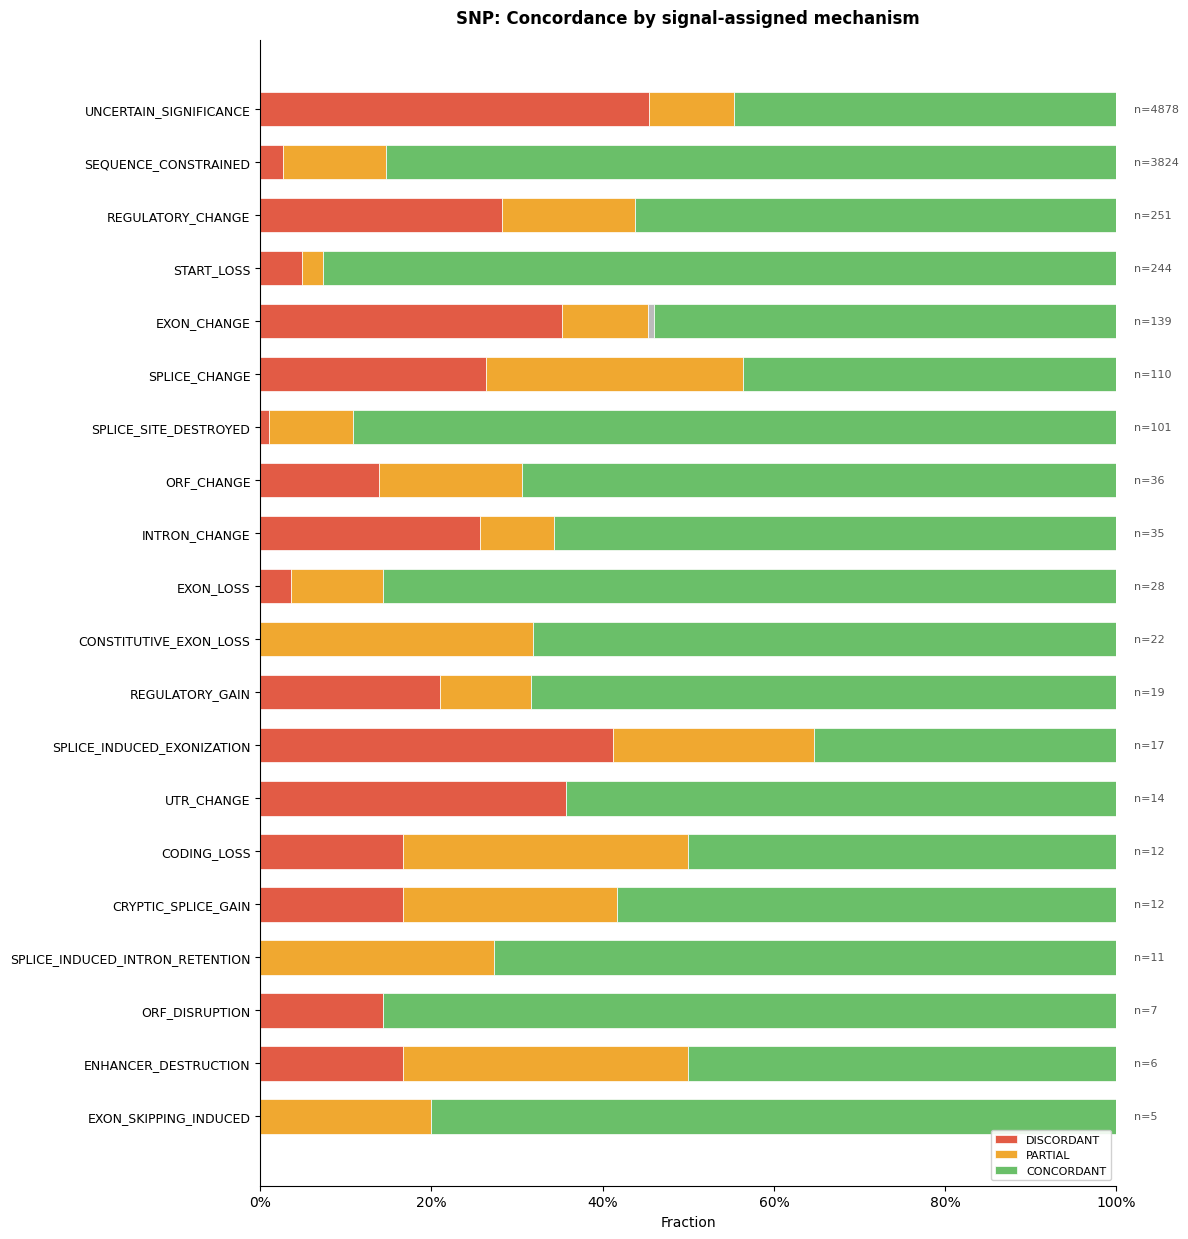

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


def plot_concordance_by_mechanism(
    df,
    vt_type,
    mechanism_col="NT_Mechanism",
    concordance_col="concordance",
    concordance_order=None,
    color_map=None,
    figsize=None,
    min_samples=0,
    exclude_from_legend=("NOT_APPLICABLE",),
):
    """
    Horizontal stacked bar chart of concordance fractions per NT mechanism.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain `mechanism_col` and `concordance_col`.
    mechanism_col : str
        Column with mechanism labels.
    concordance_col : str
        Column with concordance categories (e.g. CONCORDANT, PARTIAL, ...).
    concordance_order : list[str] | None
        Display order (left→right) of concordance categories.
        Defaults to the unique values sorted with CONCORDANT last (rightmost).
    color_map : dict | None
        {category: color}. Defaults to a ClinVar-ish palette.
    figsize : tuple | None
        Figure size. Auto-scaled to number of mechanisms if None.
    title : str
        Plot title.
    min_samples : int
        Minimum number of variants per mechanism to include in plot.
        Mechanisms below this threshold are silently dropped.
    exclude_from_legend : tuple[str]
        Concordance categories to exclude from legend (still plotted).
        Defaults to ("NOT_APPLICABLE",).
    """

    # --- defaults ---
    if color_map is None:
        color_map = {
            "DISCORDANT": "#e25b45",
            "PARTIAL": "#f0a830",
            "CONCORDANT": "#6abf69",
            "NOT_APPLICABLE": "#bbbbbb",
        }
    if vt_type == "snp":
        title = "SNP: Concordance by signal-assigned mechanism"
    elif vt_type == "indel":
        title = "INDEL: Concordance by signal-assigned mechanism"

    # Cross-tab: rows = mechanisms, cols = concordance categories
    ct = pd.crosstab(df[mechanism_col], df[concordance_col])

    # Determine concordance order
    if concordance_order is None:
        cats = list(ct.columns)
        # push CONCORDANT to end so it's the rightmost (largest) bar segment
        preferred = ["DISCORDANT", "PARTIAL", "NOT_APPLICABLE", "CONCORDANT"]
        concordance_order = [c for c in preferred if c in cats]
        concordance_order += [c for c in cats if c not in concordance_order]

    ct = ct.reindex(columns=concordance_order, fill_value=0)

    # Fractions
    row_totals = ct.sum(axis=1)

    # Filter by min_samples
    if min_samples > 0:
        keep = row_totals[row_totals >= min_samples].index
        ct = ct.loc[keep]
        row_totals = row_totals.loc[keep]

    ct_frac = ct.div(row_totals, axis=0)

    # Sort mechanisms by sample count (largest on top)
    sort_idx = row_totals.sort_values(ascending=True).index
    ct_frac = ct_frac.loc[sort_idx]
    row_totals = row_totals.loc[sort_idx]

    # --- plot ---
    n_mechs = len(ct_frac)
    if figsize is None:
        figsize = (12, max(4, 0.55 * n_mechs + 1.5))

    fig, ax = plt.subplots(figsize=figsize)

    lefts = np.zeros(n_mechs)
    bars_by_cat = {}

    for cat in concordance_order:
        widths = ct_frac[cat].values
        color = color_map.get(cat, "#999999")
        b = ax.barh(
            range(n_mechs), widths, left=lefts, height=0.65,
            color=color, edgecolor="white", linewidth=0.5, label=cat,
        )
        bars_by_cat[cat] = b
        lefts += widths

    # Y labels = mechanism names
    ax.set_yticks(range(n_mechs))
    ax.set_yticklabels(ct_frac.index, fontsize=9)

    # Sample counts on the right
    for i, (mech, n) in enumerate(row_totals.items()):
        ax.text(1.02, i, f"n={n}", va="center", ha="left", fontsize=8, color="#555555")

    # Axes
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.set_xlabel("Fraction", fontsize=10)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=12)

    # Legend (exclude specified categories)
    legend_cats = [c for c in concordance_order if c in bars_by_cat and c not in exclude_from_legend]
    handles = [bars_by_cat[c] for c in legend_cats]
    ax.legend(
        handles, legend_cats,
        loc="lower right", fontsize=8, framealpha=0.9,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"figures/{vt_type}_signal_mechanism_concordance_fig.png")
    return fig, ax


if __name__ == "__main__":
    fig, ax = plot_concordance_by_mechanism(snp_res, vt_type="snp", min_samples = 5) 